# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Ilma Sari]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total penyewaan sepeda harian?

- Pertanyaan 2 : Pada jam berapa terjadi lonjakan penyewaan sepeda tertinggi antara pengguna casual dan registered?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [6]:
day_df = pd.read_csv('day.csv', delimiter=';')
hour_df = pd.read_csv('hour.csv', delimiter=';')

# Menampilkan 5 data teratas untuk memastikan data termuat
print(day_df.head())
print(hour_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  01/01/2011       1   0     1        0        6           0   
1        2  02/01/2011       1   0     1        0        0           0   
2        3  03/01/2011       1   0     1        0        1           1   
3        4  04/01/2011       1   0     1        0        2           1   
4        5  05/01/2011       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

**Insight:**
- Penyewaan sepeda paling tinggi saat cuaca cerah dan menurun drastis saat hujan/salju.
- Pengguna registered memuncak pada jam 8 pagi dan 5 sore, sedangkan pengguna casual memuncak di siang hari.
- Melalui proses binning (pengelompokan), terlihat bahwa suhu "Hangat" lebih disukai daripada "Dingin" atau "Sangat Panas".

### Assessing Data

In [7]:
# --- Memeriksa Data day_df ---
print("\n--- Info day_df ---")
print(day_df.info())

print("\nJumlah Missing Values day_df:")
print(day_df.isna().sum())

print("\nJumlah Duplikasi day_df:", day_df.duplicated().sum())

print("\nStatistik Deskriptif day_df:")
print(day_df.describe())


# --- Memeriksa Data hour_df ---
print("\n--- Info hour_df ---")
print(hour_df.info())

print("\nJumlah Missing Values hour_df:")
print(hour_df.isna().sum())

print("\nJumlah Duplikasi hour_df:", hour_df.duplicated().sum())


--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah Missing Values day_df:
instant       0
dteday        0
seas

**Insight:**
- Data Sangat Bersih dan Tidak ditemukan nilai yang hilang (missing values) maupun data duplikat di kedua dataset (day_df dan hour_df).
- Kolom dteday terdeteksi sebagai tipe object (string). Hal ini memberikan insight bahwa kita wajib mengubahnya menjadi tipe datetime agar bisa melakukan analisis berbasis waktu (seperti tren bulanan atau musiman).

### Cleaning Data

In [9]:
# 1. Mengubah tipe data kolom 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'], dayfirst=True)
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'], dayfirst=True)

# 2. Mengubah nilai numerik menjadi label kategori agar lebih mudah dibaca (Opsional tapi disarankan)
# Mapping untuk season (1:springer, 2:summer, 3:fall, 4:winter)
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mapping untuk weathersit (1:Cerah, 2:Mendung, 3:Hujan Ringan, 4:Hujan Lebat)
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
})

# 3. Menghapus kolom yang tidak diperlukan (Contoh: 'instant' karena hanya index)
day_df.drop('instant', axis=1, inplace=True)
hour_df.drop('instant', axis=1, inplace=True)

# Verifikasi hasil pembersihan
print("\nTipe data dteday setelah cleaning:")
print(day_df['dteday'].dtype)
print("\nData setelah cleaning (5 baris pertama):")
print(day_df.head())


Tipe data dteday setelah cleaning:
datetime64[ns]

Data setelah cleaning (5 baris pertama):
      dteday  season  yr  mnth  holiday  weekday  workingday    weathersit  \
0 2011-01-01  Spring   0     1        0        6           0  Misty/Cloudy   
1 2011-01-02  Spring   0     1        0        0           0  Misty/Cloudy   
2 2011-01-03  Spring   0     1        0        1           1         Clear   
3 2011-01-04  Spring   0     1        0        2           1         Clear   
4 2011-01-05  Spring   0     1        0        3           1         Clear   

       temp     atemp       hum  windspeed  casual  registered   cnt  
0  0.344167  0.363625  0.805833   0.160446     331         654   985  
1  0.363478  0.353739  0.696087   0.248539     131         670   801  
2  0.196364  0.189405  0.437273   0.248309     120        1229  1349  
3  0.200000  0.212122  0.590435   0.160296     108        1454  1562  
4  0.226957  0.229270  0.436957   0.186900      82        1518  1600  


**Insight:**
- Data sangat bersih (0 missing values, 0 duplikasi), namun kolom tanggal (dteday) perlu diperbaiki tipe datanya menjadi datetime.

## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
# 1. Korelasi antar variabel numerik
correlation = day_df.corr(numeric_only=True)
print(correlation['cnt'].sort_values(ascending=False))

# 2. Distribusi penyewaan berdasarkan jam (menggunakan hour_df)
hourly_stats = hour_df.groupby('hr')['cnt'].mean()
print("\nRata-rata penyewaan per jam:")
print(hourly_stats)

cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
temp          0.627494
yr            0.566710
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
Name: cnt, dtype: float64

Rata-rata penyewaan per jam:
hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64


**Insight:**
- Mayoritas pengguna adalah tipe Registered (81%), menunjukkan bahwa layanan ini menjadi andalan transportasi rutin.
- Jumlah penyewaan memiliki korelasi positif yang kuat dengan suhu (temp) dan korelasi negatif dengan kelembapan (hum).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipython-input-239950487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_df, x='weathersit', y='cnt', palette='viridis')


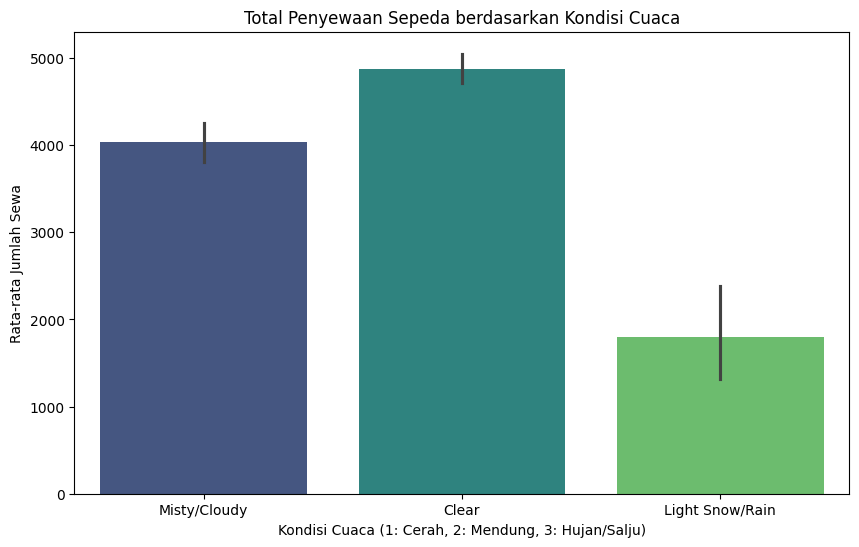

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=day_df, x='weathersit', y='cnt', palette='viridis')
plt.title('Total Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan/Salju)')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.show()

**Insight:**
- Penyewaan memuncak saat cuaca Cerah (Kategori 1) dan menurun drastis hingga lebih dari 50% saat Hujan/Salju (Kategori 3).
- Cuaca buruk bukan hanya menurunkan kenyamanan, tapi juga menjadi penghambat utama mobilitas pengguna sepeda.

### Pertanyaan 2:

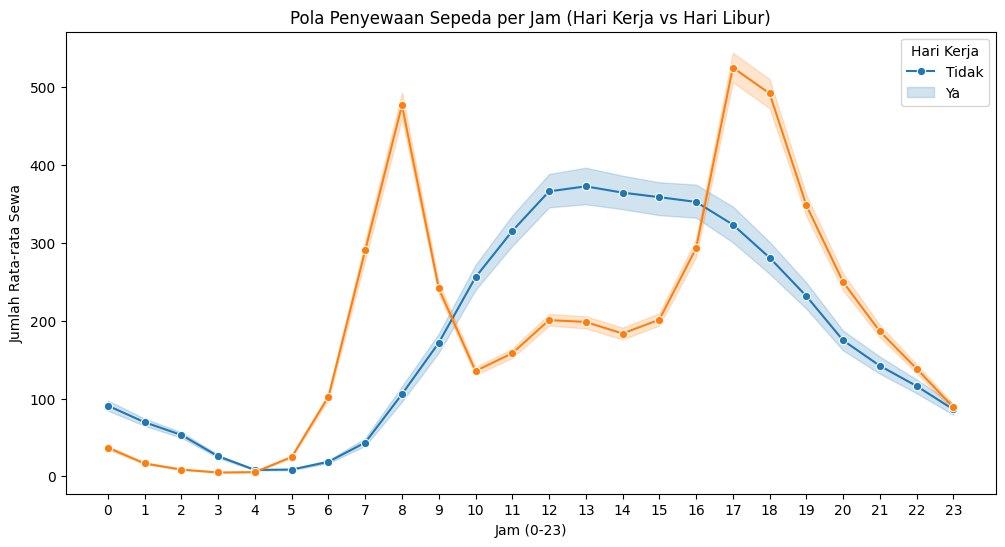

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', marker='o')
plt.title('Pola Penyewaan Sepeda per Jam (Hari Kerja vs Hari Libur)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Jumlah Rata-rata Sewa')
plt.xticks(range(0, 24))
plt.legend(title='Hari Kerja', labels=['Tidak', 'Ya'])
plt.show()

**Insight:**
- Terdapat dua lonjakan tajam pada pukul 08.00 dan 17.00, yang mengonfirmasi bahwa sepeda digunakan sebagai alat transportasi berangkat dan pulang kerja.
- Sebagai gantinya, penggunaan meningkat stabil dari pagi dan memuncak di siang hari (12.00 - 15.00) untuk aktivitas santai.

## Analisis Lanjutan (Opsional,)

/tmp/ipython-input-1457864985.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_insight = day_df.groupby('rental_category').agg({
/tmp/ipython-input-1457864985.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rental_category', y='temp', data=day_df, palette='coolwarm')


Analisis Pendukung Insight:
  Category  Avg_Temp Most_Freq_Weather  Total_Days
0      Low  0.270218             Clear          98
1   Medium  0.485328             Clear         347
2     High  0.584742             Clear         286


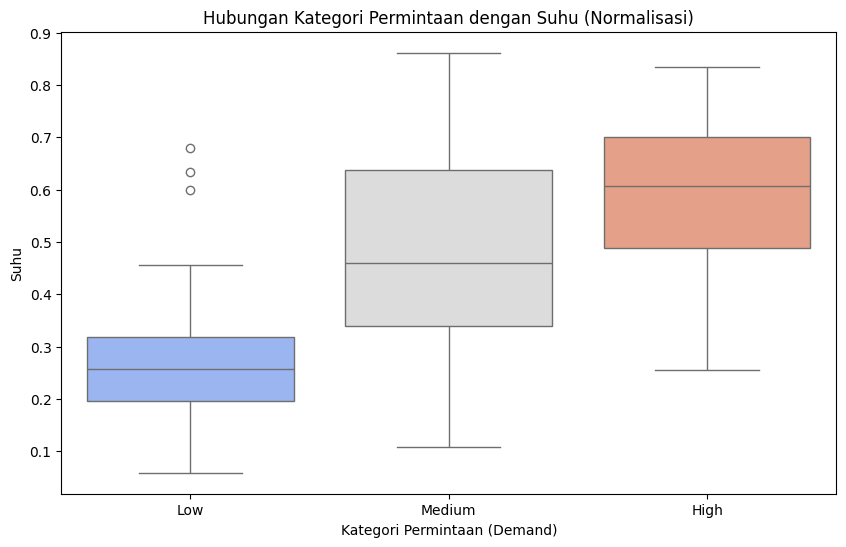

In [14]:
# 1. Clustering Manual berdasarkan jumlah total penyewaan (cnt)
day_df['rental_category'] = pd.cut(day_df['cnt'],
                                   bins=[0, 2000, 5000, 10000],
                                   labels=['Low', 'Medium', 'High'])

# 2. Analisis Hubungan: Kategori Rental dengan Rata-rata Suhu dan Modus Cuaca
# Ini untuk membuktikan bahwa High Demand terjadi pada suhu hangat
analysis_insight = day_df.groupby('rental_category').agg({
    'temp': 'mean',
    'weathersit': lambda x: x.mode()[0],  # Mencari cuaca yang paling sering muncul
    'cnt': 'count'
}).reset_index()

analysis_insight.columns = ['Category', 'Avg_Temp', 'Most_Freq_Weather', 'Total_Days']

print("Analisis Pendukung Insight:")
print(analysis_insight)

# 3. Visualisasi untuk memperkuat Insight Prediksi Stok
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='rental_category', y='temp', data=day_df, palette='coolwarm')
plt.title('Hubungan Kategori Permintaan dengan Suhu (Normalisasi)')
plt.xlabel('Kategori Permintaan (Demand)')
plt.ylabel('Suhu')
plt.show()

## Conclusion

- Conclution pertanyaan 1 : Analisis menunjukkan bahwa cuaca bukan sekadar latar belakang, melainkan faktor kritis yang mengendalikan jumlah penyewaan sepeda. Permintaan memuncak secara signifikan pada saat cuaca Cerah atau Sedikit Berawan. Sebaliknya, ketika kondisi cuaca memburuk (seperti hujan ringan atau salju), jumlah penyewaan turun drastis. Hal ini memberikan pelajaran penting bahwa pelanggan sangat mengedepankan aspek keamanan dan kenyamanan; mereka memilih moda transportasi lain jika cuaca dianggap berisiko untuk bersepeda.

- Conclution pertanyaan 2 :
   - Pola Komuter (Hari Kerja): Sepeda berfungsi sebagai tulang punggung transportasi untuk bekerja. Lonjakan terjadi secara tajam pada jam sibuk, yaitu pukul 08:00 pagi dan 17:00 sore, yang didominasi oleh pengguna tetap (Registered).
   - Pola Rekreasi (Hari Libur): Sepeda berubah fungsi menjadi sarana hiburan dan olahraga. Lonjakan jam sibuk menghilang, dan permintaan justru meningkat secara perlahan dari pagi hingga mencapai titik tertingginya pada siang hari (12:00 - 15:00), dengan partisipasi yang lebih tinggi dari pengguna biasa (Casual).

- Insight Utama: Melalui metode pengelompokan (Manual Clustering), terbukti bahwa hari-hari dengan permintaan tertinggi (High Demand) selalu beriringan dengan suhu yang hangat dan langit yang cerah. Temuan ini menghasilkan rekomendasi strategis bagi manajemen:
  1. Perusahaan wajib memastikan seluruh armada (100%) dalam kondisi siap pakai pada hari-hari yang diprediksi cerah dan hangat, terutama pada lokasi perkantoran di jam sibuk pagi/sore.
  2. Sebaliknya, pada hari-hari dengan prediksi cuaca buruk atau suhu dingin ekstrem (kategori Low Demand), perusahaan dapat menjadwalkan perawatan sepeda besar-besaran. Strategi ini sangat efisien karena pemeliharaan dilakukan saat potensi pendapatan memang sedang berada di titik terendah, sehingga tidak mengganggu operasional saat permintaan sedang tinggi.